In [3]:
!pip install scikit-learn matplotlib numpy requests pillow

=== K-Means Clustering ===


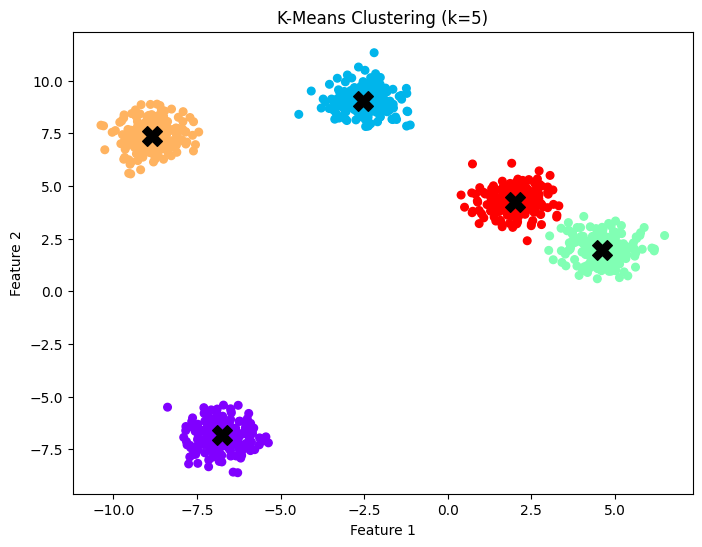

=== MiniBatch K-Means ===
MiniBatch K-Means fitted successfully!
=== Finding Optimal k using Silhouette Score ===
k=2, Silhouette Score: 0.613
k=3, Silhouette Score: 0.745
k=4, Silhouette Score: 0.805
k=5, Silhouette Score: 0.797
k=6, Silhouette Score: 0.695
k=7, Silhouette Score: 0.579
k=8, Silhouette Score: 0.501
k=9, Silhouette Score: 0.393


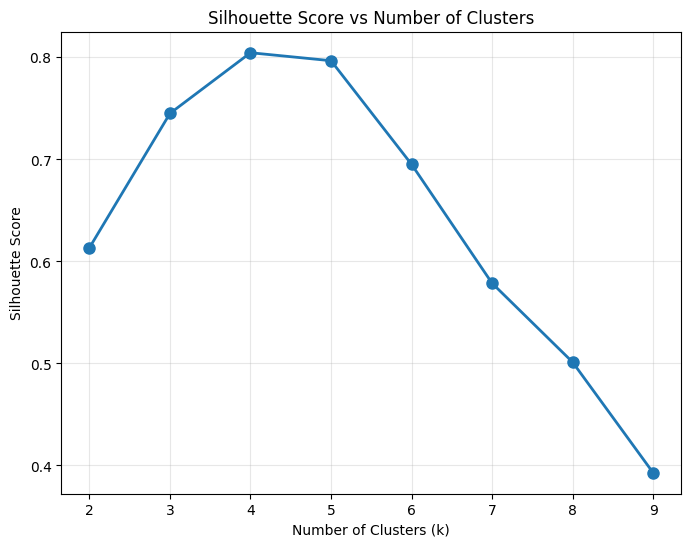

Optimal k: 4 with score: 0.805
=== Image Segmentation with K-Means ===
Error in image segmentation: cannot identify image file <_io.BytesIO object at 0x78a96bec3e20>
Skipping image segmentation section...
=== Clustering for Preprocessing ===


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline Accuracy with KMeans Preprocessing: 0.9722
Baseline Accuracy (no preprocessing): 0.9750
=== DBSCAN Clustering ===
Number of clusters: 2
Number of noise points: 0


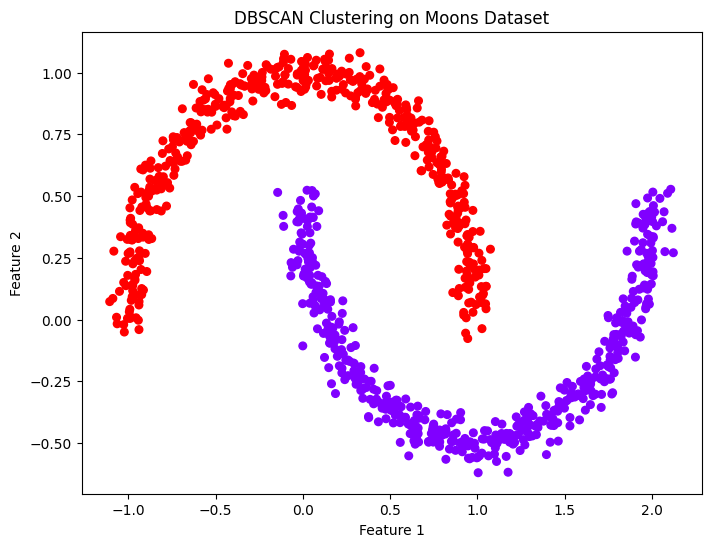

=== Gaussian Mixture Model ===


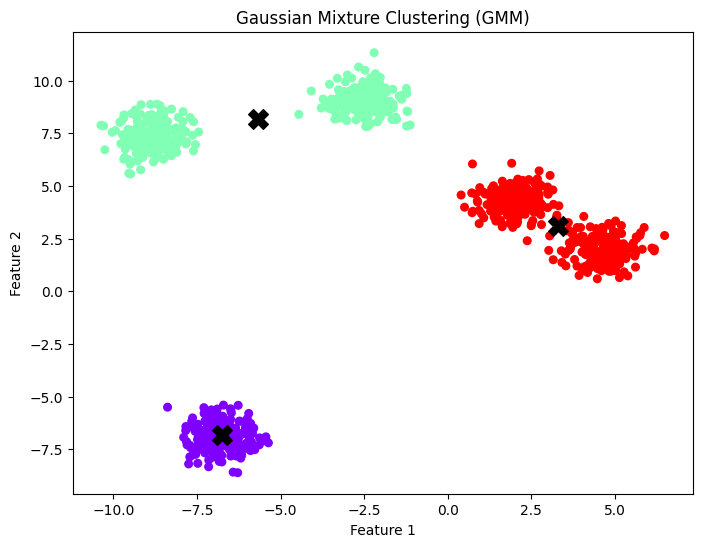

GMM Weights: [0.2 0.4 0.4]
GMM Log-likelihood: -3.987522472554905
=== Anomaly Detection using GMM ===


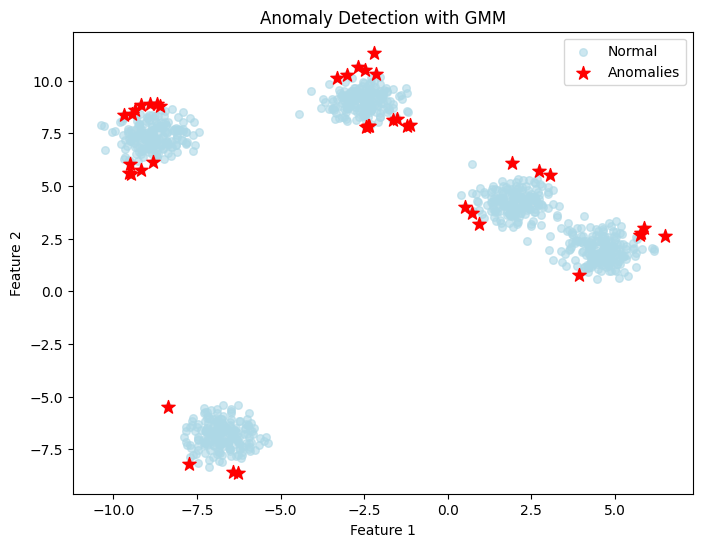

Number of anomalies detected: 40
Anomaly threshold: -5.730
=== Bayesian Gaussian Mixture ===
Bayesian Gaussian Mixture Weights: [0.201 0.203 0.2   0.2   0.197 0.    0.    0.    0.    0.   ]
Number of active components: 5


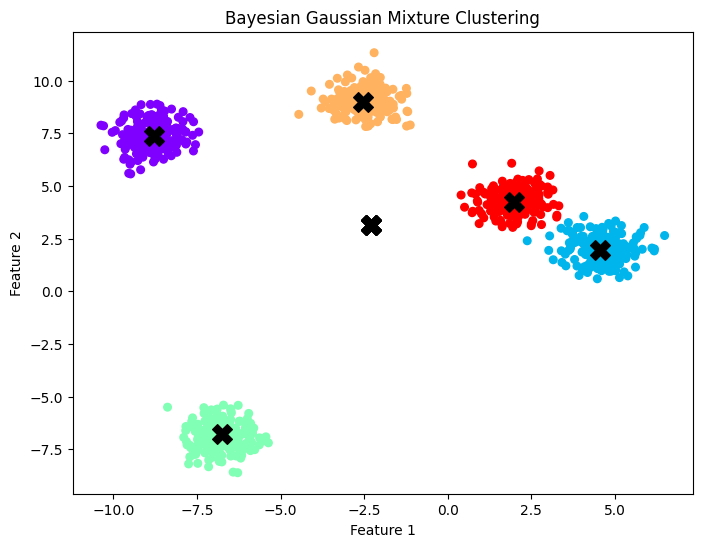

=== All clustering algorithms completed successfully! ===


In [4]:
# ✅ Install library (jalankan jika belum ada)
# !pip install scikit-learn matplotlib numpy requests pillow

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, load_digits
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
import requests
from PIL import Image
import io

##############################################
# 1️⃣ K-Means Clustering
##############################################
print("=== K-Means Clustering ===")
X, _ = make_blobs(n_samples=1000, centers=5, cluster_std=0.6, random_state=42)
k = 5
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
y_pred = kmeans.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap="rainbow", s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
           color="black", marker="X", s=200)
plt.title("K-Means Clustering (k=5)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

##############################################
# 2️⃣ MiniBatch K-Means
##############################################
print("=== MiniBatch K-Means ===")
minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=42)
minibatch_kmeans.fit(X)
print("MiniBatch K-Means fitted successfully!")

##############################################
# 3️⃣ Silhouette Score for Optimal k
##############################################
print("=== Finding Optimal k using Silhouette Score ===")
scores = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    score = silhouette_score(X, km.labels_)
    scores.append(score)
    print(f"k={k}, Silhouette Score: {score:.3f}")

plt.figure(figsize=(8, 6))
plt.plot(k_range, scores, marker="o", linewidth=2, markersize=8)
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.3)
plt.show()

optimal_k = k_range[np.argmax(scores)]
print(f"Optimal k: {optimal_k} with score: {max(scores):.3f}")

##############################################
# 4️⃣ Image Segmentation with K-Means (FIXED)
##############################################
print("=== Image Segmentation with K-Means ===")
try:
    # Download image using requests instead of imread with URL
    url = "https://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/Ladybug_on_leaf.jpg/640px-Ladybug_on_leaf.jpg"
    response = requests.get(url)
    image = np.array(Image.open(io.BytesIO(response.content)))

    # Reshape image for clustering
    original_shape = image.shape
    X_img = image.reshape(-1, 3)

    # Apply K-means clustering
    kmeans_img = KMeans(n_clusters=8, random_state=42, n_init=10)
    kmeans_img.fit(X_img)

    # Reconstruct segmented image
    segmented_img = kmeans_img.cluster_centers_[kmeans_img.labels_]
    segmented_img = segmented_img.reshape(original_shape)

    # Display results
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Segmented Image (k=8)")
    plt.imshow(segmented_img.astype(np.uint8))
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print("Image segmentation completed successfully!")

except Exception as e:
    print(f"Error in image segmentation: {e}")
    print("Skipping image segmentation section...")

##############################################
# 5️⃣ Clustering for Preprocessing (Digits Dataset)
##############################################
print("=== Clustering for Preprocessing ===")
X_digits, y_digits = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits,
                                                    test_size=0.2, random_state=42)

# Pipeline with KMeans preprocessing
pipeline = Pipeline([
    ("kmeans", KMeans(n_clusters=50, random_state=42, n_init=10)),
    ("log_reg", LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(X_train, y_train)
pipeline_score = pipeline.score(X_test, y_test)
print(f"Pipeline Accuracy with KMeans Preprocessing: {pipeline_score:.4f}")

# Compare with baseline (no preprocessing)
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train, y_train)
baseline_score = baseline.score(X_test, y_test)
print(f"Baseline Accuracy (no preprocessing): {baseline_score:.4f}")

##############################################
# 6️⃣ DBSCAN Example
##############################################
print("=== DBSCAN Clustering ===")
X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_db = dbscan.fit_predict(X_moons)

# Count clusters and noise points
n_clusters = len(set(y_db)) - (1 if -1 in y_db else 0)
n_noise = list(y_db).count(-1)
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

plt.figure(figsize=(8, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_db, cmap="rainbow", s=30)
plt.title("DBSCAN Clustering on Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

##############################################
# 7️⃣ Gaussian Mixture Model (GMM)
##############################################
print("=== Gaussian Mixture Model ===")
gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)
y_gmm = gm.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_gmm, cmap="rainbow", s=30)
plt.scatter(gm.means_[:, 0], gm.means_[:, 1], color="black", marker="X", s=200)
plt.title("Gaussian Mixture Clustering (GMM)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("GMM Weights:", np.round(gm.weights_, 3))
print("GMM Log-likelihood:", gm.score(X))

##############################################
# 8️⃣ Anomaly Detection using GMM
##############################################
print("=== Anomaly Detection using GMM ===")
densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 4)  # Bottom 4% as anomalies
anomalies = X[densities < density_threshold]

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c="lightblue", alpha=0.6, s=30, label="Normal")
plt.scatter(anomalies[:, 0], anomalies[:, 1], color="red", marker="*",
           s=100, label="Anomalies")
plt.title("Anomaly Detection with GMM")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

print(f"Number of anomalies detected: {len(anomalies)}")
print(f"Anomaly threshold: {density_threshold:.3f}")

##############################################
# 9️⃣ Bayesian Gaussian Mixture (automatic number of clusters)
##############################################
print("=== Bayesian Gaussian Mixture ===")
bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X)
weights = bgm.weights_
print("Bayesian Gaussian Mixture Weights:", np.round(weights, 3))

# Show which components are actually used (weight > 0.01)
active_components = np.sum(weights > 0.01)
print(f"Number of active components: {active_components}")

# Plot BGM results
y_bgm = bgm.predict(X)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_bgm, cmap="rainbow", s=30)
plt.scatter(bgm.means_[:, 0], bgm.means_[:, 1], color="black", marker="X", s=200)
plt.title("Bayesian Gaussian Mixture Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("=== All clustering algorithms completed successfully! ===")

# 📚 Chapter 9 - Unsupervised Learning Techniques

---

## 🔸 1. Apa Itu Unsupervised Learning?
**Unsupervised Learning** = Machine Learning **tanpa label** → algoritma mencari pola atau struktur tersembunyi dalam data.

---

## 🔸 2. Clustering
**Clustering** = Mengelompokkan data ke dalam grup (cluster) berdasarkan kesamaan fitur.

| Algoritma       | Keterangan                                  |
| --------------- | ------------------------------------------- |
| **K-Means**     | Membagi data ke k cluster berdasarkan jarak |
| **DBSCAN**      | Mengelompokkan berdasarkan kepadatan        |
| **Gaussian Mixture (GMM)** | Probabilistic clustering menggunakan Gaussian Distribution |

---

## 🔸 3. K-Means Clustering
**Cara kerja:**
1. Pilih k pusat cluster secara acak
2. Iterasi:
   - Tetapkan data ke pusat cluster terdekat
   - Update pusat cluster → rata-rata titik dalam cluster

**Kelemahan:**
- Harus menentukan **k**
- Tidak cocok untuk cluster berbentuk non-bulat

**Evaluasi:**
- **Silhouette Score** → menilai seberapa baik data dipisahkan antar cluster

---

## 🔸 4. Mini-Batch K-Means
Versi lebih cepat dari K-Means → memproses subset data secara bertahap → cocok untuk dataset besar.

---

## 🔸 5. Image Segmentation dengan K-Means
- K-Means dapat digunakan untuk mengelompokkan warna gambar → mengurangi jumlah warna → kompresi/segmentasi gambar.

---

## 🔸 6. DBSCAN (Density-Based Spatial Clustering)
- **Tidak memerlukan jumlah cluster** → cocok untuk data dengan bentuk tidak beraturan.
- Mengidentifikasi:
  - **Core points** → titik dalam area padat
  - **Border points** → di sekitar core points
  - **Noise points** → dianggap outlier

---

## 🔸 7. Gaussian Mixture Models (GMM)
- **Probabilistic Clustering**
- Tiap cluster direpresentasikan sebagai **Gaussian distribution**
- Bisa memodelkan **overlapping clusters**
- **Soft clustering** → memberikan probabilitas keanggotaan, bukan hard assignment

---

## 🔸 8. Anomaly Detection dengan GMM
- Titik dengan densitas probabilitas rendah → dianggap sebagai **anomali/outlier**

---

## 🔸 9. Bayesian Gaussian Mixture
- **Menyesuaikan jumlah cluster secara otomatis** → bisa digunakan ketika jumlah cluster tidak diketahui.
- Menggunakan **prior distribution** → mencegah model memilih terlalu banyak cluster.

---

## ✅ Kesimpulan
| Teknik          | Kapan Digunakan                            |
| --------------- | ------------------------------------------ |
| **K-Means**     | Clustering sederhana, cepat                |
| **Mini-Batch K-Means** | Dataset besar                         |
| **DBSCAN**      | Data berbentuk kompleks / ada outlier      |
| **GMM**         | Soft clustering, data dengan overlap       |
| **Bayesian GMM** | Tidak tahu pasti jumlah cluster           |

